<a href="https://colab.research.google.com/github/sowjanyakaranam/Sentiment_Metamorphic_Testing/blob/dev/Sentiment_Metamorphic_Testing_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sentiment Metamorphic Testing Experiment

Initial setup

In [3]:
pip install transformers datasets torch pandas matplotlib # All packages were successfully installed.

Initial Code

In [6]:
import random
import pandas as pd
from datasets import load_dataset
from transformers import pipeline

random.seed(42)

# -----------------------------
# 1. Load Dataset
# -----------------------------
dataset = load_dataset("sst2", split="validation")
samples = dataset.select(range(200))  # use 200 examples for a small experiment

texts = list(samples["sentence"])

# -----------------------------
# 2. Load Pretrained Sentiment Model
# -----------------------------
classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

# -----------------------------
# 3. Text Transformations
# -----------------------------

synonym_map = {
    "good": "great",
    "bad": "poor",
    "happy": "pleased",
    "sad": "unhappy",
    "excellent": "amazing",
    "terrible": "awful",
    "nice": "pleasant",
    "boring": "dull",
    "funny": "humorous",
    "love": "like",
    "hate": "dislike"
}

def synonym_replacement(text):
    words = text.split()
    new_words = []
    for word in words:
        clean = word.lower().strip(".,!?")
        if clean in synonym_map:
            new_words.append(synonym_map[clean])
        else:
            new_words.append(word)
    return " ".join(new_words)

def typo_injection(text):
    words = text.split()
    if not words:
        return text

    idx = random.randint(0, len(words) - 1)
    word = words[idx]

    if len(word) > 4:
        # remove one character from the middle
        mid = len(word) // 2
        words[idx] = word[:mid] + word[mid + 1:]
    return " ".join(words)

def word_order_change(text):
    words = text.split()
    if len(words) < 4:
        return text

    # simple swap of first two words
    words[0], words[1] = words[1], words[0]
    return " ".join(words)

def negation_insertion(text):
    words = text.split()
    if len(words) < 3:
        return "not " + text

    # insert "not" before first common sentiment-bearing adjective if found
    sentiment_words = [
        "good", "great", "excellent", "amazing", "nice",
        "bad", "terrible", "awful", "boring", "poor"
    ]

    for i, word in enumerate(words):
        clean = word.lower().strip(".,!?")
        if clean in sentiment_words:
            words.insert(i, "not")
            return " ".join(words)

    return "not " + text

# -----------------------------
# 4. Prediction Function
# -----------------------------

def predict_batch(text_list, batch_size=32):
    outputs = classifier(text_list, batch_size=batch_size, truncation=True)
    return [
        {
            "label": item["label"],
            "confidence": item["score"]
        }
        for item in outputs
    ]

# -----------------------------
# 5. Run Metamorphic Tests
# -----------------------------

transformations = {
    "Synonym Replacement": synonym_replacement,
    "Typo Injection": typo_injection,
    "Word Order Change": word_order_change,
    "Negation": negation_insertion
}

results = []

original_preds = predict_batch(texts)

for transform_name, transform_func in transformations.items():
    transformed_texts = [transform_func(text) for text in texts]
    transformed_preds = predict_batch(transformed_texts)

    for i in range(len(texts)):
        original_label = original_preds[i]["label"]
        transformed_label = transformed_preds[i]["label"]

        original_conf = original_preds[i]["confidence"]
        transformed_conf = transformed_preds[i]["confidence"]

        same_prediction = original_label == transformed_label
        confidence_change = original_conf - transformed_conf

        results.append({
            "transformation": transform_name,
            "original_text": texts[i],
            "transformed_text": transformed_texts[i],
            "original_label": original_label,
            "transformed_label": transformed_label,
            "same_prediction": same_prediction,
            "original_confidence": original_conf,
            "transformed_confidence": transformed_conf,
            "confidence_change": confidence_change
        })

df = pd.DataFrame(results)

# -----------------------------
# 6. Compute Metrics
# -----------------------------

summary = []

for transform_name in transformations.keys():
    subset = df[df["transformation"] == transform_name]

    if transform_name == "Negation":
        metric_name = "Flip Accuracy"
        metric_value = (~subset["same_prediction"]).mean()
    else:
        metric_name = "Consistency Score"
        metric_value = subset["same_prediction"].mean()

    avg_conf_change = subset["confidence_change"].mean()

    summary.append({
        "Transformation": transform_name,
        "Metric": metric_name,
        "Score": round(metric_value * 100, 2),
        "Avg Confidence Change": round(avg_conf_change, 4)
    })

summary_df = pd.DataFrame(summary)

print("\n=== Summary Results ===")
print(summary_df)

print("\n=== Sample Violations ===")
violations = df[
    ((df["transformation"] != "Negation") & (df["same_prediction"] == False)) |
    ((df["transformation"] == "Negation") & (df["same_prediction"] == True))
]

print(violations[[
    "transformation",
    "original_text",
    "transformed_text",
    "original_label",
    "transformed_label",
    "original_confidence",
    "transformed_confidence"
]].head(10))

# Save results
df.to_csv("metamorphic_testing_detailed_results.csv", index=False)
summary_df.to_csv("metamorphic_testing_summary.csv", index=False)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== Summary Results ===
        Transformation             Metric  Score  Avg Confidence Change
0  Synonym Replacement  Consistency Score  100.0                 0.0011
1       Typo Injection  Consistency Score   98.5                 0.0045
2    Word Order Change  Consistency Score   96.5                 0.0005
3             Negation      Flip Accuracy   28.5                 0.0145

=== Sample Violations ===
        transformation                                      original_text  \
335     Typo Injection  pumpkin means to be an outrageous dark satire ...   
371     Typo Injection  rarely has leukemia looked so shimmering and b...   
384     Typo Injection  though perry and hurley make inspiring efforts...   
464  Word Order Change  the script kicks in , and mr. hartley 's diste...   
466  Word Order Change  if you 're hard up for raunchy college humor ,...   
483  Word Order Change  though it 's become almost redundant to say so...   
512  Word Order Change                hilariously

Visualizing data

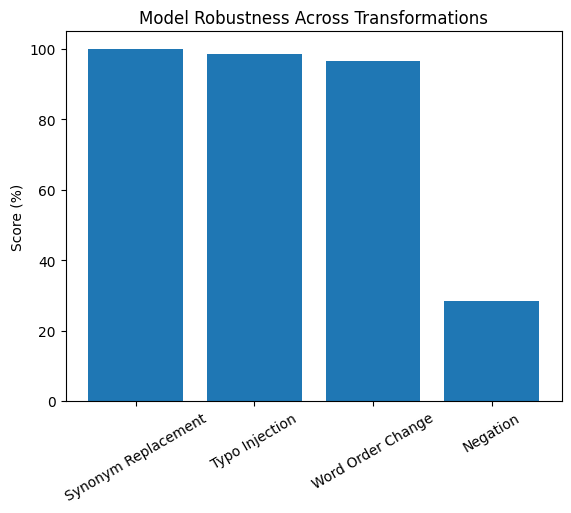

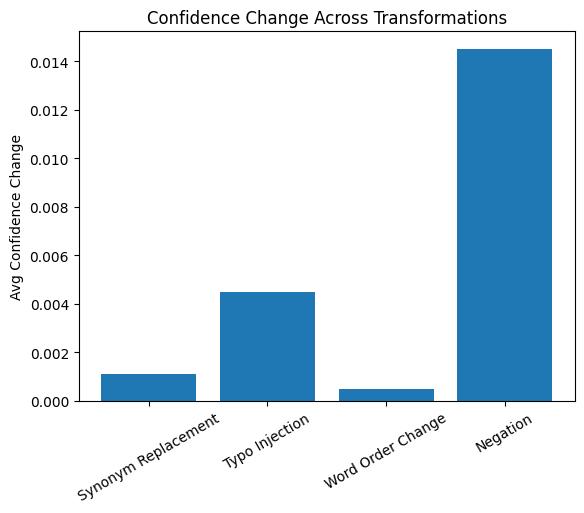

In [7]:
import matplotlib.pyplot as plt

# Bar chart for scores
plt.figure()
plt.bar(summary_df["Transformation"], summary_df["Score"])
plt.ylabel("Score (%)")
plt.title("Model Robustness Across Transformations")
plt.xticks(rotation=30)
plt.show()

# Bar chart for confidence drop
plt.figure()
plt.bar(summary_df["Transformation"], summary_df["Avg Confidence Change"])
plt.ylabel("Avg Confidence Change")
plt.title("Confidence Change Across Transformations")
plt.xticks(rotation=30)
plt.show()

More visualization

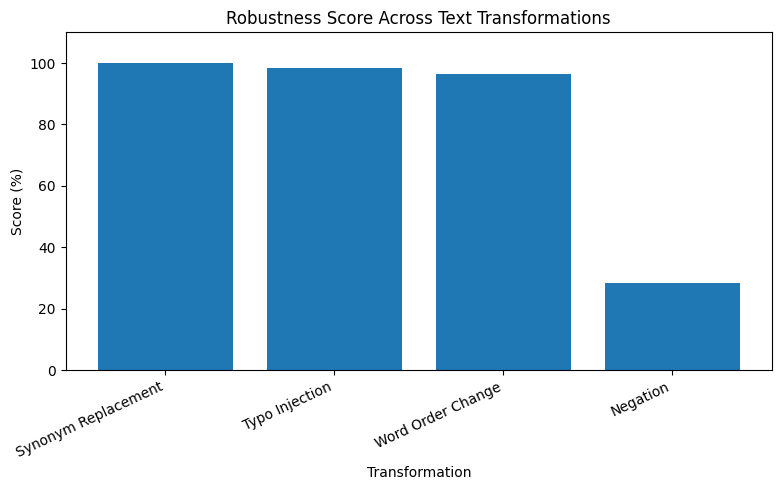

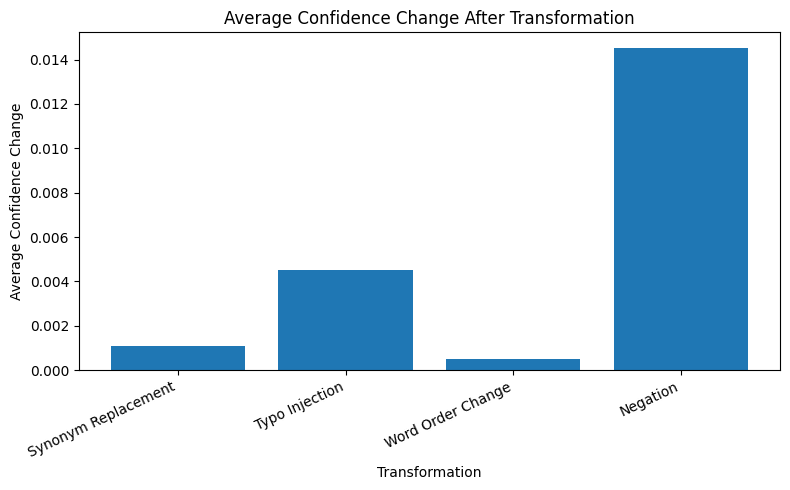

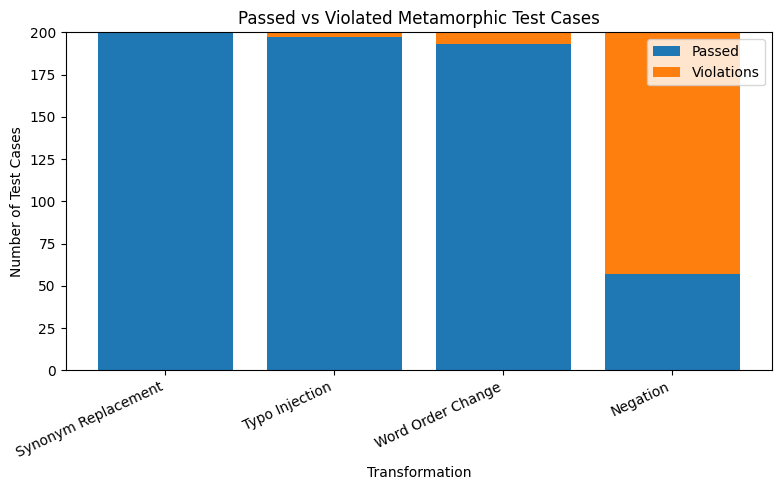

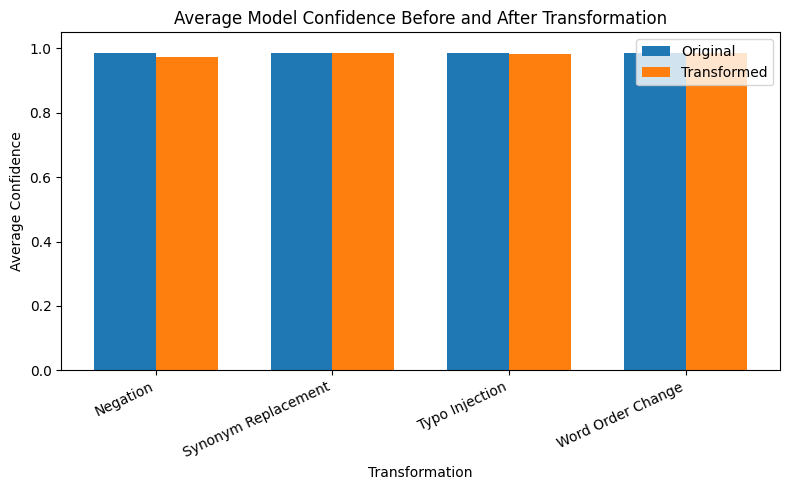

,transformation,original_text,transformed_text,original_label,transformed_label,original_confidence,transformed_confidence
335,Typo Injection,pumpkin means to be an outrageous dark satire ...,pumpkin means to be an outrageous dark satire ...,POSITIVE,NEGATIVE,0.920258,0.604436
371,Typo Injection,rarely has leukemia looked so shimmering and b...,rarly has leukemia looked so shimmering and be...,POSITIVE,NEGATIVE,0.977942,0.994050
384,Typo Injection,though perry and hurley make inspiring efforts...,though perry and hurley make inspiring efforts...,POSITIVE,NEGATIVE,0.663869,0.725728
464,Word Order Change,"the script kicks in , and mr. hartley 's diste...","script the kicks in , and mr. hartley 's diste...",POSITIVE,NEGATIVE,0.857641,0.976678
466,Word Order Change,"if you 're hard up for raunchy college humor ,...","you if 're hard up for raunchy college humor ,...",POSITIVE,NEGATIVE,0.831661,0.750877
483,Word Order Change,though it 's become almost redundant to say so...,it though 's become almost redundant to say so...,POSITIVE,NEGATIVE,0.903023,0.998472
512,Word Order Change,hilariously inept and ridiculous .,inept hilariously and ridiculous .,POSITIVE,NEGATIVE,0.982423,0.927256
572,Word Order Change,it seems like i have been waiting my whole lif...,seems it like i have been waiting my whole lif...,POSITIVE,NEGATIVE,0.744148,0.926499
592,Word Order Change,"a celebration of quirkiness , eccentricity , a...","celebration a of quirkiness , eccentricity , a...",POSITIVE,NEGATIVE,0.980923,0.922612
595,Word Order Change,my thoughts were focused on the characters .,thoughts my were focused on the characters .,POSITIVE,NEGATIVE,0.922242,0.832317


In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# 1. Robustness Score Chart
# -----------------------------
plt.figure(figsize=(8, 5))
plt.bar(summary_df["Transformation"], summary_df["Score"])
plt.ylabel("Score (%)")
plt.xlabel("Transformation")
plt.title("Robustness Score Across Text Transformations")
plt.ylim(0, 110)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("figure_1_robustness_score.png", dpi=300)
plt.show()


# -----------------------------
# 2. Confidence Change Chart
# -----------------------------
plt.figure(figsize=(8, 5))
plt.bar(summary_df["Transformation"], summary_df["Avg Confidence Change"])
plt.ylabel("Average Confidence Change")
plt.xlabel("Transformation")
plt.title("Average Confidence Change After Transformation")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("figure_2_confidence_change.png", dpi=300)
plt.show()


# -----------------------------
# 3. Pass vs Violation Count
# -----------------------------
plot_rows = []

for transform_name in transformations.keys():
    subset = df[df["transformation"] == transform_name]

    if transform_name == "Negation":
        passed = (~subset["same_prediction"]).sum()
        failed = subset["same_prediction"].sum()
    else:
        passed = subset["same_prediction"].sum()
        failed = (~subset["same_prediction"]).sum()

    plot_rows.append({
        "Transformation": transform_name,
        "Passed": passed,
        "Violations": failed
    })

pass_fail_df = pd.DataFrame(plot_rows)

plt.figure(figsize=(8, 5))
plt.bar(pass_fail_df["Transformation"], pass_fail_df["Passed"], label="Passed")
plt.bar(
    pass_fail_df["Transformation"],
    pass_fail_df["Violations"],
    bottom=pass_fail_df["Passed"],
    label="Violations"
)
plt.ylabel("Number of Test Cases")
plt.xlabel("Transformation")
plt.title("Passed vs Violated Metamorphic Test Cases")
plt.xticks(rotation=25, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("figure_3_pass_vs_violation.png", dpi=300)
plt.show()


# -----------------------------
# 4. Confidence Before vs After
# -----------------------------
avg_conf = df.groupby("transformation")[["original_confidence", "transformed_confidence"]].mean().reset_index()

x = range(len(avg_conf))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], avg_conf["original_confidence"], width, label="Original")
plt.bar([i + width/2 for i in x], avg_conf["transformed_confidence"], width, label="Transformed")

plt.ylabel("Average Confidence")
plt.xlabel("Transformation")
plt.title("Average Model Confidence Before and After Transformation")
plt.xticks(x, avg_conf["transformation"], rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig("figure_4_confidence_before_after.png", dpi=300)
plt.show()


# -----------------------------
# 5. Save Clean Violation Examples
# -----------------------------
violation_examples = violations[[
    "transformation",
    "original_text",
    "transformed_text",
    "original_label",
    "transformed_label",
    "original_confidence",
    "transformed_confidence"
]].head(10)

violation_examples.to_csv("sample_violation_examples.csv", index=False)

violation_examples